In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
from pathlib import Path

ZIP_PATH = Path("/content/drive/MyDrive/bachelor_thesis_data/gan/melanoma_train_512.zip")

EXTRACT_ROOT = Path("/content/diffusion_melanoma_dataset_clean")
TRAIN_DIR = EXTRACT_ROOT / "00000"

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/bachelor_thesis_data/diffusion/sdxl_melanoma_lora_run1"
)

MODEL_NAME = "stabilityai/stable-diffusion-xl-base-1.0"
VAE_NAME = "madebyollin/sdxl-vae-fp16-fix"
INSTANCE_PROMPT = "a dermoscopic photograph of sks melanoma, centered pigmented skin lesion"
VALIDATION_PROMPT = "a high quality dermoscopic photograph of sks melanoma, centered pigmented skin lesion"
EXPECTED_IMAGES = 943

assert ZIP_PATH.is_file(), f"ZIP not found: {ZIP_PATH}"
print("ZIP:", ZIP_PATH)
print("Training images:", TRAIN_DIR)
print("Output:", OUTPUT_DIR)

ZIP: /content/drive/MyDrive/bachelor_thesis_data/gan/melanoma_train_512.zip
Training images: /content/diffusion_melanoma_dataset_clean/00000
Output: /content/drive/MyDrive/bachelor_thesis_data/diffusion/sdxl_melanoma_lora_run1


In [ ]:
import zipfile

if EXTRACT_ROOT.exists():
    print(f"Reusing existing extraction: {EXTRACT_ROOT}")
else:
    EXTRACT_ROOT.mkdir(parents=True)
    with zipfile.ZipFile(ZIP_PATH, "r") as archive:
        archive.extractall(EXTRACT_ROOT)
    print(f"Extracted archive once to: {EXTRACT_ROOT}")

assert TRAIN_DIR.is_dir(), (
    f"Expected the ZIP to create {TRAIN_DIR}. "
    f"Top-level contents: {list(EXTRACT_ROOT.iterdir())}"
)

Extracted archive once to: /content/diffusion_melanoma_dataset_clean


In [ ]:
from collections import Counter
from PIL import Image

IMAGE_SUFFIXES = {".png", ".jpg", ".jpeg", ".webp"}
direct_entries = list(TRAIN_DIR.iterdir())
image_paths = sorted(
    p for p in direct_entries
    if p.is_file() and p.suffix.lower() in IMAGE_SUFFIXES
)
unexpected_entries = sorted(p for p in direct_entries if p not in image_paths)

dimensions = Counter()
for image_path in image_paths:
    with Image.open(image_path) as image:
        image.verify()
    with Image.open(image_path) as image:
        dimensions[image.size] += 1

print("Direct images:", len(image_paths))
print("Dimensions:", dimensions)
print("Unexpected entries:", unexpected_entries)

assert len(image_paths) == EXPECTED_IMAGES, (
    f"Expected {EXPECTED_IMAGES} direct images, found {len(image_paths)}"
)
assert not unexpected_entries, (
    "TRAIN_DIR contains a non-image file or nested directory. "
    "Do not use recursive image discovery for DreamBooth training."
)
assert dimensions == Counter({(512, 512): EXPECTED_IMAGES}), dimensions
print("Dataset validation passed.")

Direct images: 943
Dimensions: Counter({(512, 512): 943})
Unexpected entries: []
Dataset validation passed.


In [ ]:
import torch

assert torch.cuda.is_available(), "Enable a GPU runtime before continuing."
gpu = torch.cuda.get_device_properties(0)
print("GPU:", gpu.name)
print(f"VRAM: {gpu.total_memory / 1024**3:.1f} GiB")

GPU: NVIDIA A100-SXM4-40GB
VRAM: 39.5 GiB


In [ ]:
%%bash
set -e

if [ ! -d /content/diffusers/.git ]; then
  git clone --branch v0.39.0 --depth 1 https://github.com/huggingface/diffusers.git /content/diffusers
else
  git -C /content/diffusers fetch --tags --quiet
  git -C /content/diffusers checkout --quiet v0.39.0
fi

python -m pip install --quiet -e /content/diffusers
python -m pip install --quiet -r /content/diffusers/examples/dreambooth/requirements_sdxl.txt
python -m pip install --quiet --upgrade "peft==0.19.1" bitsandbytes xformers tensorboard

if python -m pip show torchao >/dev/null 2>&1; then
  python -m pip uninstall -y torchao
fi

accelerate config default

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.3/168.3 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 68.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 125.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 134.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 35.3 MB/s eta 0:00:00
Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0
accelerate configuration saved at /root/.cache/huggingface/accelerate/default_config.yaml


Cloning into '/content/diffusers'...
Note: switching to 'a3608b512ed7248499a44c61d954965ed9bdae4d'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.35.1 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.35.1 which is incompatible.
goo

In [ ]:
import importlib
import sys

for module_name in list(sys.modules):
    if module_name == "diffusers" or module_name.startswith("diffusers."):
        del sys.modules[module_name]
    if module_name == "peft" or module_name.startswith("peft."):
        del sys.modules[module_name]

sys.path.insert(0, "/content/diffusers/src")
importlib.invalidate_caches()

import diffusers
import peft
from diffusers import AutoencoderKL, DiffusionPipeline

print("Diffusers:", diffusers.__version__)
print("Diffusers path:", diffusers.__file__)
print("PEFT:", peft.__version__)

assert diffusers.__version__.startswith("0.39.0"), diffusers.__version__
assert peft.__version__ == "0.19.1", peft.__version__
print("Environment validation passed.")

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Diffusers: 0.39.0
Diffusers path: /content/diffusers/src/diffusers/__init__.py
PEFT: 0.19.1
Environment validation passed.


In [ ]:
import gc
import torch
from IPython.display import display
from diffusers import AutoencoderKL, DiffusionPipeline

BASELINE_DIR = OUTPUT_DIR / "before_training"
BASELINE_DIR.mkdir(parents=True, exist_ok=True)
baseline_paths = [BASELINE_DIR / f"seed_{seed}.png" for seed in range(4)]

if all(path.exists() for path in baseline_paths):
    print("Baseline images already exist; generation skipped.")
else:
    vae = AutoencoderKL.from_pretrained(
        VAE_NAME,
        torch_dtype=torch.float16,
    )
    pipe = DiffusionPipeline.from_pretrained(
        MODEL_NAME,
        vae=vae,
        torch_dtype=torch.float16,
        variant="fp16",
        use_safetensors=True,
    ).to("cuda")

    for seed, save_path in enumerate(baseline_paths):
        generator = torch.Generator(device="cuda").manual_seed(seed)
        image = pipe(
            VALIDATION_PROMPT,
            num_inference_steps=40,
            guidance_scale=7.0,
            height=512,
            width=512,
            generator=generator,
        ).images[0]
        image.save(save_path)
        display(image)

    del pipe, vae
    gc.collect()
    torch.cuda.empty_cache()
    print("Saved baseline images to:", BASELINE_DIR)

In [ ]:
import os

current_images = [
    p for p in TRAIN_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in IMAGE_SUFFIXES
]
assert len(current_images) == EXPECTED_IMAGES
assert not any(p.is_dir() for p in TRAIN_DIR.iterdir())

final_lora = OUTPUT_DIR / "pytorch_lora_weights.safetensors"
checkpoints = sorted(OUTPUT_DIR.glob("checkpoint-*")) if OUTPUT_DIR.exists() else []
assert not final_lora.exists(), "This run already has final LoRA weights."
assert not checkpoints, (
    f"Found existing checkpoints: {checkpoints}. Use the resume cell instead."
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
os.environ.update({
    "MODEL_NAME": MODEL_NAME,
    "VAE_NAME": VAE_NAME,
    "TRAIN_DIR": str(TRAIN_DIR),
    "OUTPUT_DIR": str(OUTPUT_DIR),
    "INSTANCE_PROMPT": INSTANCE_PROMPT,
    "VALIDATION_PROMPT": VALIDATION_PROMPT,
})

print(f"Ready to train on {len(current_images)} images")
print("TRAIN_DIR =", os.environ["TRAIN_DIR"])
print("OUTPUT_DIR =", os.environ["OUTPUT_DIR"])

Ready to train on 943 images
TRAIN_DIR = /content/diffusion_melanoma_dataset_clean/00000
OUTPUT_DIR = /content/drive/MyDrive/bachelor_thesis_data/diffusion/sdxl_melanoma_lora_run1


In [ ]:
!accelerate launch /content/diffusers/examples/dreambooth/train_dreambooth_lora_sdxl.py           --pretrained_model_name_or_path="$MODEL_NAME"           --pretrained_vae_model_name_or_path="$VAE_NAME"           --instance_data_dir="$TRAIN_DIR"           --output_dir="$OUTPUT_DIR"           --instance_prompt="$INSTANCE_PROMPT"           --validation_prompt="$VALIDATION_PROMPT"           --resolution=512           --train_batch_size=4           --gradient_accumulation_steps=1           --learning_rate=1e-4           --lr_scheduler="constant"           --lr_warmup_steps=0           --max_train_steps=2000           --checkpointing_steps=500           --checkpoints_total_limit=4           --validation_epochs=2           --num_validation_images=4           --rank=32           --mixed_precision="bf16"           --random_flip           --seed=42           --report_to="tensorboard"

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
08/17/2026 20:18:43 - INFO - __main__ - [RANK 0] Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: bf16

08/17/2026 20:18:43 - INFO - httpx - HTTP Request: GET https://huggingface.co/api/agent-harnesses "HTTP/1.1 200 OK"
08/17/2026 20:18:44 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/stabilityai/stable-diffusion-xl-base-1.0/resolve/main/tokenizer/config.json "HTTP/1.1 404 Not Found"
08/17/2026 20:18:44 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/stabilityai/stable-diffusion-xl-base-1.0/resolve/main/tokenizer/config.json "HTTP/1.1 404 Not Found"
08/17/2026 20:18:44 - WARNING - 

In [ ]:
final_lora = OUTPUT_DIR / "pytorch_lora_weights.safetensors"
assert final_lora.is_file(), f"Final LoRA weights not found: {final_lora}"
print("Training completed.")
print("LoRA weights:", final_lora)
print(f"Size: {final_lora.stat().st_size / 1024**2:.1f} MiB")

Training completed.
LoRA weights: /content/drive/MyDrive/bachelor_thesis_data/diffusion/sdxl_melanoma_lora_run1/pytorch_lora_weights.safetensors
Size: 177.3 MiB


In [ ]:
import gc
import torch
from pathlib import Path
from diffusers import AutoencoderKL, DiffusionPipeline
from IPython.display import display

CHECKPOINT_STEPS = [500, 1000, 1500, 2000]
SEEDS = [0, 1, 2, 3]

COMPARISON_DIR = OUTPUT_DIR / "checkpoint_comparison"
COMPARISON_DIR.mkdir(parents=True, exist_ok=True)

# Confirm that every checkpoint and LoRA file exists
for step in CHECKPOINT_STEPS:
    checkpoint_dir = OUTPUT_DIR / f"checkpoint-{step}"
    lora_file = checkpoint_dir / "pytorch_lora_weights.safetensors"

    assert checkpoint_dir.is_dir(), f"Missing: {checkpoint_dir}"
    assert lora_file.is_file(), f"Missing: {lora_file}"

print("All four checkpoints found.")

vae = AutoencoderKL.from_pretrained(
    VAE_NAME,
    torch_dtype=torch.float16,
)

pipe = DiffusionPipeline.from_pretrained(
    MODEL_NAME,
    vae=vae,
    torch_dtype=torch.float16,
    variant="fp16",
    use_safetensors=True,
).to("cuda")

pipe.set_progress_bar_config(disable=False)

for step in CHECKPOINT_STEPS:
    checkpoint_dir = OUTPUT_DIR / f"checkpoint-{step}"
    step_dir = COMPARISON_DIR / f"checkpoint-{step}"
    step_dir.mkdir(parents=True, exist_ok=True)

    print(f"\nLoading checkpoint {step}...")

    pipe.load_lora_weights(
        str(checkpoint_dir),
        weight_name="pytorch_lora_weights.safetensors",
    )

    for seed in SEEDS:
        save_path = step_dir / f"seed_{seed}.png"

        if save_path.exists():
            print(f"Already exists, skipping: {save_path.name}")
            continue

        generator = torch.Generator(
            device="cuda"
        ).manual_seed(seed)

        image = pipe(
            prompt=VALIDATION_PROMPT,
            negative_prompt=(
                "clinical photograph, body, face, multiple lesions, "
                "text, watermark, diagram, illustration, blurry, "
                "low quality, distorted"
            ),
            height=512,
            width=512,
            num_inference_steps=40,
            guidance_scale=7.0,
            generator=generator,
        ).images[0]

        image.save(save_path)

    pipe.unload_lora_weights()

    print(f"Generated checkpoint {step}")

del pipe, vae
gc.collect()
torch.cuda.empty_cache()

print("\nSaved samples to:", COMPARISON_DIR)

All four checkpoints found.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 17 files:   0%|          | 0/17 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

...

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

Generated checkpoint 2000

Saved samples to: /content/drive/MyDrive/bachelor_thesis_data/diffusion/sdxl_melanoma_lora_run1/checkpoint_comparison


In [ ]:
import gc
import torch
from diffusers import AutoencoderKL, DiffusionPipeline

SEEDS = [0, 1, 2, 3]

BEFORE_DIR = OUTPUT_DIR / "checkpoint_comparison" / "before_training"
BEFORE_DIR.mkdir(parents=True, exist_ok=True)

NEGATIVE_PROMPT = (
    "clinical photograph, body, face, multiple lesions, "
    "text, watermark, diagram, illustration, blurry, "
    "low quality, distorted"
)

vae = AutoencoderKL.from_pretrained(
    VAE_NAME,
    torch_dtype=torch.float16,
)

pipe = DiffusionPipeline.from_pretrained(
    MODEL_NAME,
    vae=vae,
    torch_dtype=torch.float16,
    variant="fp16",
    use_safetensors=True,
).to("cuda")

for seed in SEEDS:
    save_path = BEFORE_DIR / f"seed_{seed}.png"

    generator = torch.Generator(
        device="cuda"
    ).manual_seed(seed)

    image = pipe(
        prompt=VALIDATION_PROMPT,
        negative_prompt=NEGATIVE_PROMPT,
        height=512,
        width=512,
        num_inference_steps=40,
        guidance_scale=7.0,
        generator=generator,
    ).images[0]

    image.save(save_path)
    print("Saved:", save_path)

del pipe, vae
gc.collect()
torch.cuda.empty_cache()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

...

Saved: /content/drive/MyDrive/bachelor_thesis_data/diffusion/sdxl_melanoma_lora_run1/checkpoint_comparison/before_training/seed_1.png


  0%|          | 0/40 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/bachelor_thesis_data/diffusion/sdxl_melanoma_lora_run1/checkpoint_comparison/before_training/seed_2.png


  0%|          | 0/40 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/bachelor_thesis_data/diffusion/sdxl_melanoma_lora_run1/checkpoint_comparison/before_training/seed_3.png


Grid saved to: /content/drive/MyDrive/bachelor_thesis_data/diffusion/sdxl_melanoma_lora_run1/checkpoint_comparison/checkpoint_comparison_grid.png


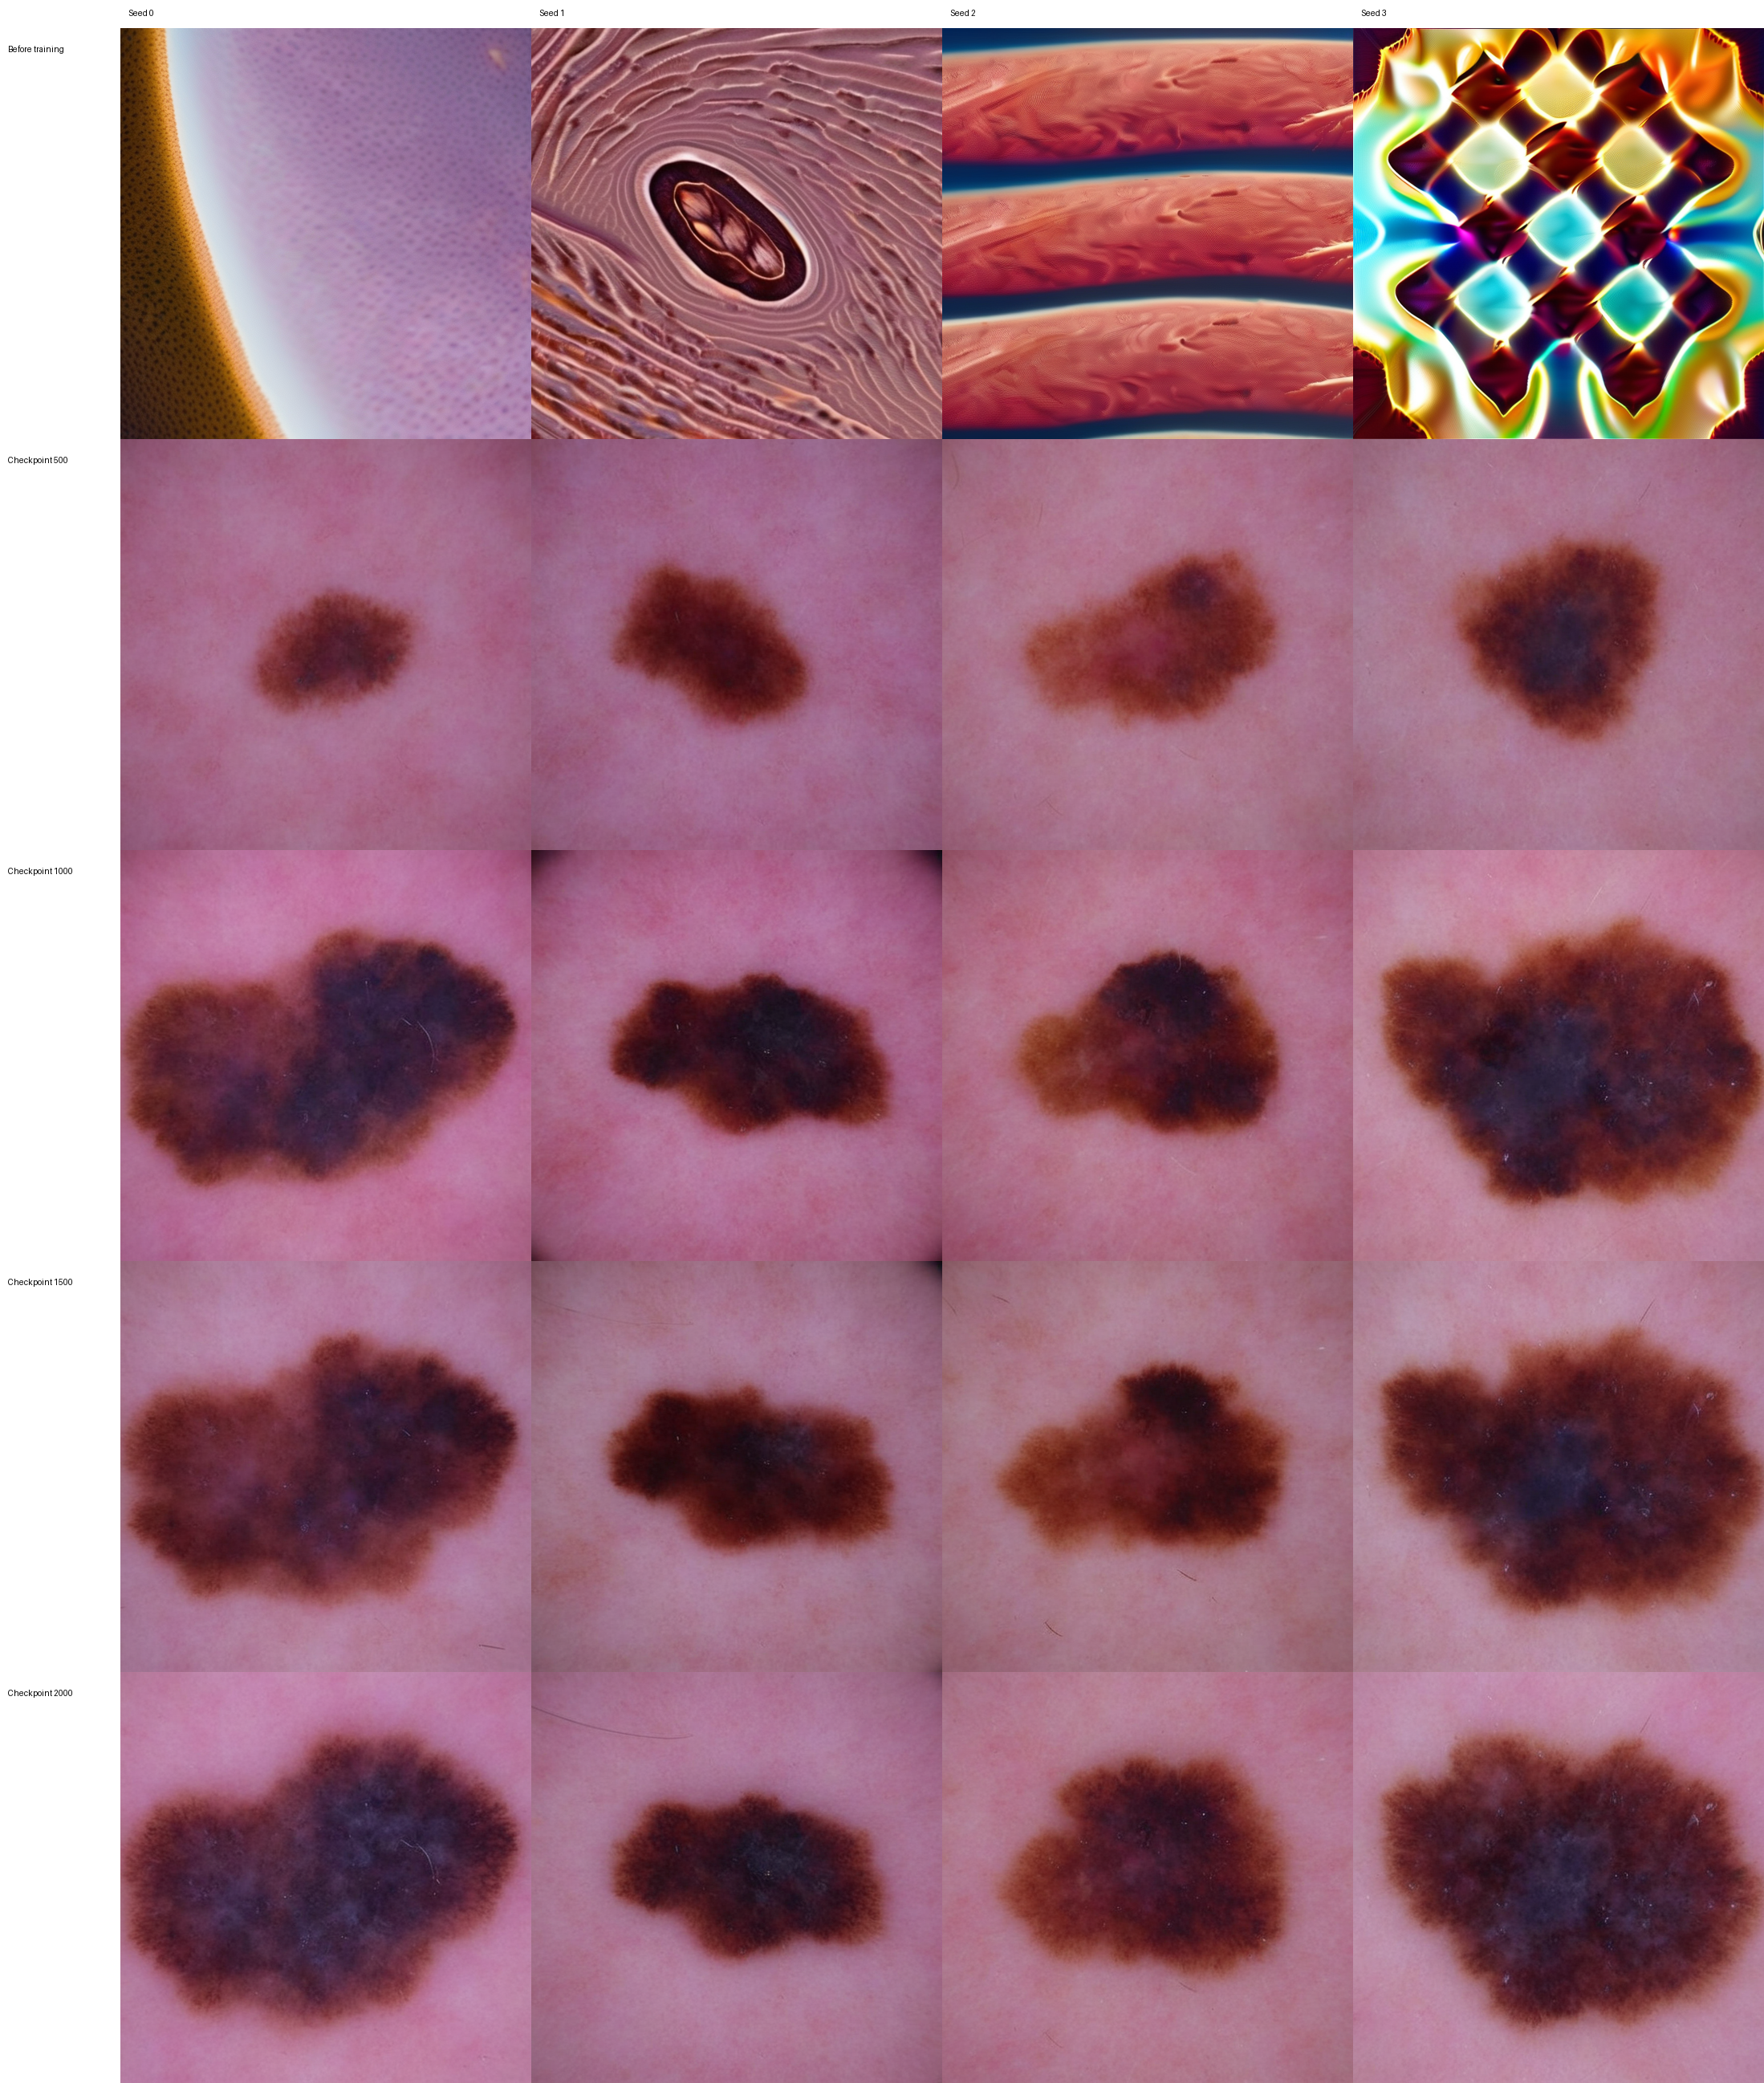

In [ ]:
from PIL import Image, ImageDraw
from IPython.display import display

rows = [
    ("Before training", COMPARISON_DIR / "before_training"),
    ("Checkpoint 500", COMPARISON_DIR / "checkpoint-500"),
    ("Checkpoint 1000", COMPARISON_DIR / "checkpoint-1000"),
    ("Checkpoint 1500", COMPARISON_DIR / "checkpoint-1500"),
    ("Checkpoint 2000", COMPARISON_DIR / "checkpoint-2000"),
]

tile_size = 512
label_width = 150
header_height = 35

grid_width = label_width + len(SEEDS) * tile_size
grid_height = header_height + len(rows) * tile_size

grid = Image.new(
    "RGB",
    (grid_width, grid_height),
    color="white"
)

draw = ImageDraw.Draw(grid)

#column labels
for column, seed in enumerate(SEEDS):
    x = label_width + column * tile_size + 10
    draw.text(
        (x, 10),
        f"Seed {seed}",
        fill="black"
    )

#images and row labels
for row_index, (row_name, directory) in enumerate(rows):
    y = header_height + row_index * tile_size

    draw.text(
        (10, y + 20),
        row_name,
        fill="black"
    )

    for column, seed in enumerate(SEEDS):
        image_path = directory / f"seed_{seed}.png"

        assert image_path.is_file(), (
            f"Image missing: {image_path}"
        )

        with Image.open(image_path) as image:
            image = image.convert("RGB").resize(
                (tile_size, tile_size)
            )

            x = label_width + column * tile_size
            grid.paste(image, (x, y))

grid_path = COMPARISON_DIR / "checkpoint_comparison_grid.png"
grid.save(grid_path)

print("Grid saved to:", grid_path)
display(grid)